# Examen visión computacional
---

## Instrucciones
---

1. Revisa el dataset que se incluye en las celdas siguientes.
2. En base a este, crea un clasificador que pueda decir el tipo de coche y su color.
3. Llena las celdas de código como se va solicitando.
4. Al terminar, sube el notebook con todas las celdas ejecutadas a canvas.

## Imports

In [ ]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install numpy pandas matplotlib opencv-python pillow lightning torchmetrics scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (4.1 MB)
  Using cached https://download.pytorch.org/whl/filelock-3.19.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2025.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Using cached https://download.pytorch.org/whl/mpmath-1.3.0-py3-none-any.whl (536 kB)
  Using cached https://download.pyto

In [2]:
import numpy as np
import cv2
import os

import torch
import torch.nn.functional as F
from torch import optim, nn, utils, Tensor
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.dataset import random_split

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import torchvision
import torchmetrics
from torchvision import transforms
from torchvision import models
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt

## Descarga del dataset

In [2]:
!rm -r cars
!rm cars_multilabel.zip
!curl -L -o ./cars_multilabel.zip https://www.kaggle.com/api/v1/datasets/download/julichitai/multilabel-small-car-and-color-dataset
!unzip -d cars cars_multilabel.zip > /dev/null

"rm" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"rm" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0  240M    0  882k    0     0  1153k      0  0:03:33 --:--:--  0:03:33 1153k
  5  240M    5 13.8M    0     0  8039k      0  0:00:30  0:00:01  0:00:29 12.9M
 13  240M   13 32.9M    0     0  11.8M      0  0:00:20  0:00:02  0:00:18 15.9M
 21  240M   21 50.6M    0     0  13.4M      0  0:00:17  0:00:03  0:00:14 16.5M
 30  240M   30 73.8M    0     0  15.5M      0  0:00:15  0:00:04  0:00:11 18.2M
 38  240M   38 92.8M    0     0  16.0M      0  0:00:14  0:00:05  0:00:09 18.3M
 46  240M   46  

In [3]:
!ls cars

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Visualización de imágenes **(5 puntos)**
---

**TO DO**: Visualiza una imagen de cada clase.

In [3]:
# TODO: Plot an image from the dataset using matplotlib
base_path = os.getenv("COMP_VISION_PATH")

dataset_root = os.path.join(base_path, "cars_multilabel")
dataset = ImageFolder(root=dataset_root)

classes = dataset.classes
class_to_idx = dataset.class_to_idx

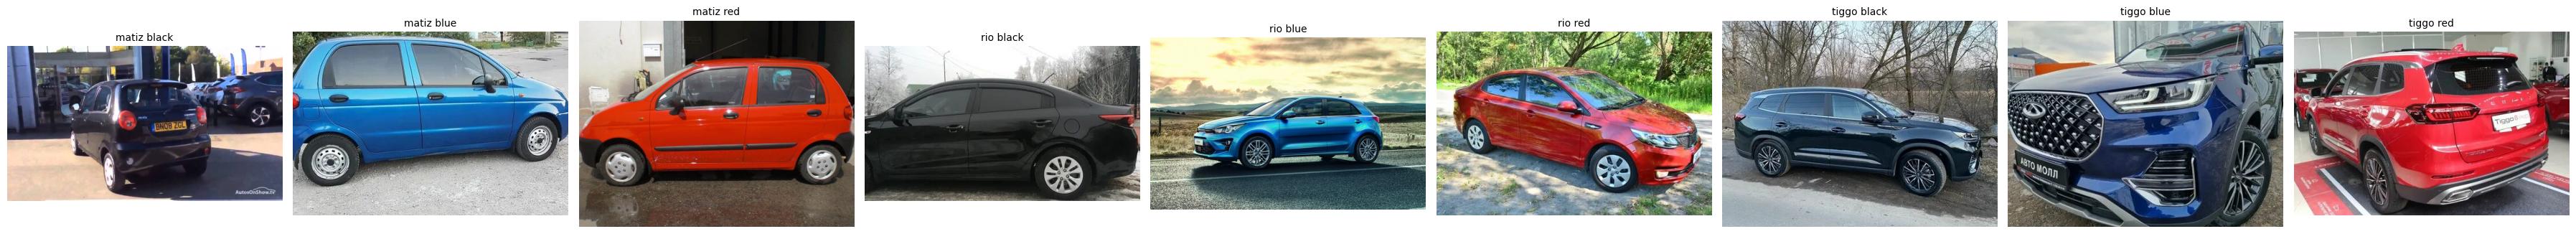

In [4]:
num_classes = len(classes)

fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))

if num_classes == 1:
    axes = [axes]

# Para cada clase, elegir un índice aleatorio del dataset
for i, class_name in enumerate(classes):
    class_idx = class_to_idx[class_name]

    # índices de todas las imágenes de esa clase
    indices = [j for j, (_, y) in enumerate(dataset) if y == class_idx]

    rand_idx = np.random.choice(indices)

    image, label = dataset[rand_idx]

    ax = axes[i]
    ax.imshow(image)
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Carga de imágenes en dataloaders **(15 puntos)**
---

**TO DO**: Construye los dataloaders necesarios, con las transformaciónes adecuadas, y muestra un batch. Connstruye las etiquetas de las imágenes para poder hacer clasificación multi-etiqueta.

In [5]:
image_transforms = transforms.Compose([

        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.2),
        transforms.RandomRotation(45/2),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])

In [6]:
full_dataset = ImageFolder(root=dataset_root, transform=image_transforms)

split_percentage = 0.8
train_size = int(split_percentage * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=25, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=25, shuffle=False)


## Definición del modelo **(15 puntos)**
---

**TO DO**: Crea un modelo con capas convolucionales para hacer la clasificación.

In [7]:
resnet_model = models.resnet152(weights=None)
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, num_classes)

class CnnModel(L.LightningModule):
    def __init__(self, model, learning_rate, num_classes):
        super().__init__()

        self.learning_rate = learning_rate
        self.model = model

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        features, true_labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, true_labels)

        return loss, logits, true_labels

    def training_step(self, batch, batch_idx):
        loss, logits, true_labels = self._shared_step(batch)

        self.log("train_loss", loss)
        self.train_acc(logits, true_labels)
        self.log("train_acc", self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logits, true_labels = self._shared_step(batch)

        self.log("val_loss", loss, prog_bar=True)
        self.val_acc(logits, true_labels)
        self.log("val_acc", self.val_acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        with torch.no_grad():
            loss, logits, true_labels = self._shared_step(batch)
            self.test_acc(logits, true_labels)
            self.log("test_acc", self.test_acc)

    def configure_optimizers(self):
        optimizer = torch.optim.RMSprop(self.parameters(), lr=self.learning_rate)
        return optimizer


In [8]:
print(torch.cuda.is_available())

True


In [ ]:
car_classifier = CnnModel(
    model=resnet_model,
    learning_rate=1e-4,
    num_classes=num_classes
)

best_model_checkpoint = ModelCheckpoint(
    dirpath="checkpoints/",
    filename="car_classifier_best",
    save_top_k=1,
    monitor="val_loss",
    mode="min"
)

car_trainer = L.Trainer(
    accelerator="gpu",          # o "auto" si quieres
    max_epochs=15,
    logger=CSVLogger(save_dir="logs/", name="car_classifier"),
    callbacks=[best_model_checkpoint]
)

car_trainer.fit(
    model=car_classifier,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model     | ResNet             | 58.2 M | train | 0    
1 | train_acc | MulticlassAccuracy | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy | 0      | train | 0    
3 | test_acc  | MulticlassAccuracy | 0      | train | 0    
-----------------------------------------------------------------
58.2 M    Trainable params
0         Non-trainable params
58.2 M    Total params
232.649   Total estimated model params size (MB)
426       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\calvo\OneDrive\Documentos\TC3007C\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\calvo\OneDrive\Documentos\TC3007C\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 0:   6%|▌         | 5/88 [01:31<25:16,  0.05it/s, v_num=0]

## Entrenamiento **(5 puntos)**
---

**TO DO**: Entrena el modelo, y muestra los resultados de validación y entrenamiento.

## Pruebas **(5 puntos)**
---

**TO DO**: Prueba el desempeño de tu modelo con datos de prueba.

## Predicción **(5 puntos)**
---

**TO DO**: Descarga una imagen, y haz una predicción sobre ella. Usa wget como en el siguiente ejemplo.

In [17]:
!wget -O matiz_rojo.jpg https://i.pinimg.com/736x/83/90/e7/8390e7fb457d2b87f98483982ebe4a62.jpg

--2024-11-05 18:20:48--  https://i.pinimg.com/736x/83/90/e7/8390e7fb457d2b87f98483982ebe4a62.jpg
Resolving i.pinimg.com (i.pinimg.com)... 23.210.215.163, 23.210.215.178, 23.210.215.161, ...
Connecting to i.pinimg.com (i.pinimg.com)|23.210.215.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44979 (44K) [image/jpeg]
Saving to: ‘matiz_rojo.jpg’

matiz_rojo.jpg      100%[===================>]  43.92K  --.-KB/s    in 0.004s  

2024-11-05 18:20:48 (11.8 MB/s) - ‘matiz_rojo.jpg’ saved [44979/44979]



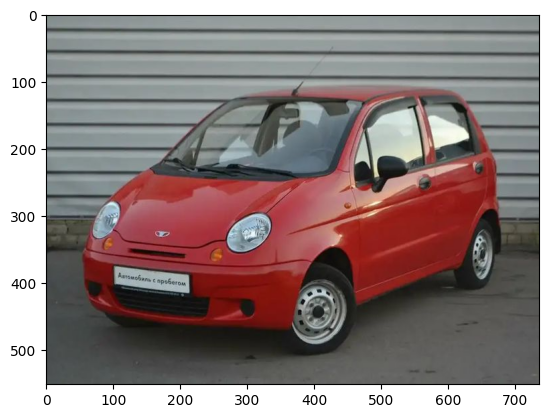

In [19]:
image = cv2.imread('matiz_rojo.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)